# 07 Economic Analysis

## Purpose

This notebook evaluates the economic dimension of Germany's international travel performance using Eurostat Balance of Payments travel statistics.

The analysis examines:

- international travel receipts
- international travel expenditure
- the travel balance
- the receipts-to-expenditure relationship
- the contribution of EU27 and Extra-EU27 partner groups
- changes in Germany's travel economic position from 2021 to 2025

The objective is to determine whether Germany's strong tourism scale is accompanied by a similarly strong international travel-receipts position and to identify the main economic pattern underlying its tourism competitiveness.

## Analytical Scope

The analysis covers 2021–2025.

The 2025 Balance of Payments observations are provisional and are interpreted accordingly.

Eurostat Balance of Payments travel statistics and accommodation statistics represent different statistical systems and scopes. Travel receipts and expenditure therefore should not be interpreted as directly equivalent to accommodation-sector revenue or spending by the visitors represented in the accommodation datasets.

For this reason, this notebook analyzes Balance of Payments indicators primarily within their own statistical framework. Cross-system comparisons with accommodation arrivals or overnight stays are treated only as contextual indicators where methodologically appropriate.

## Business Questions

1. How have Germany's international travel receipts developed since 2021?
2. How has outbound travel expenditure developed over the same period?
3. Has Germany's travel balance improved or deteriorated?
4. How much expenditure is offset by incoming travel receipts?
5. What proportion of Germany's travel receipts comes from EU27 versus Extra-EU27 partners?
6. Has Germany's geographic receipts structure changed materially?
7. What do these economic indicators imply for Germany's tourism competitiveness?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.max_rows",
    100
)

project_root = Path.cwd().parent

clean_dir = (
    project_root
    / "data"
    / "clean"
)

processed_dir = (
    project_root
    / "data"
    / "processed"
)

figures_dir = (
    project_root
    / "figures"
)

print(
    "Project root:",
    project_root
)

Project root: /Users/jannoelvero/Documents/germany_eu_tourism_analysis


In [2]:
bop = pd.read_csv(
    clean_dir
    / "germany_travel_bop_annual_clean.csv"
)

print(
    "BoP shape:",
    bop.shape
)

display(
    bop.head(10)
)

BoP shape: (30, 10)


,country_code,country,partner_code,partner,flow_code,year,travel_mio_eur,status,value_available,is_provisional
0,DE,Germany,EU27_2020,EU27,CRE,2021,13317.0,NaN,True,NaN
1,DE,Germany,EU27_2020,EU27,CRE,2022,20539.0,NaN,True,NaN
2,DE,Germany,EU27_2020,EU27,CRE,2023,23223.0,NaN,True,NaN
3,DE,Germany,EU27_2020,EU27,CRE,2024,24860.0,NaN,True,NaN
4,DE,Germany,EU27_2020,EU27,CRE,2025,25711.0,p,True,True
5,DE,Germany,EU27_2020,EU27,DEB,2021,34061.0,NaN,True,NaN
6,DE,Germany,EU27_2020,EU27,DEB,2022,60740.0,NaN,True,NaN
7,DE,Germany,EU27_2020,EU27,DEB,2023,73692.0,NaN,True,NaN
8,DE,Germany,EU27_2020,EU27,DEB,2024,71236.0,NaN,True,NaN
9,DE,Germany,EU27_2020,EU27,DEB,2025,75502.0,p,True,True


In [3]:
print(
    bop.info()
)

display(
    bop.dtypes
)

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country_code     30 non-null     str    
 1   country          30 non-null     str    
 2   partner_code     30 non-null     str    
 3   partner          30 non-null     str    
 4   flow_code        30 non-null     str    
 5   year             30 non-null     int64  
 6   travel_mio_eur   30 non-null     float64
 7   status           6 non-null      str    
 8   value_available  30 non-null     bool   
 9   is_provisional   6 non-null      object 
dtypes: bool(1), float64(1), int64(1), object(1), str(6)
memory usage: 2.3+ KB
None


country_code           str
country                str
partner_code           str
partner                str
flow_code              str
year                 int64
travel_mio_eur     float64
status                 str
value_available       bool
is_provisional      object
dtype: object

In [4]:
print(
    "Years:",
    sorted(
        bop[
            "year"
        ].unique()
    )
)

print(
    "\nPartner groups:"
)

print(
    bop[
        "partner"
    ]
    .drop_duplicates()
    .tolist()
)

Years: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Partner groups:
['EU27', 'Extra-EU27']


In [5]:
for column in bop.columns:
    if bop[column].dtype == "object":
        print(
            f"\n{column}:"
        )

        print(
            bop[column]
            .drop_duplicates()
            .tolist()
        )


is_provisional:
[nan, True]


In [6]:
print(
    "Flow codes:",
    bop[
        "flow_code"
    ]
    .drop_duplicates()
    .tolist()
)

print(
    "\nPartner codes:",
    bop[
        "partner_code"
    ]
    .drop_duplicates()
    .tolist()
)

print(
    "\nCountries:",
    bop[
        [
            "country_code",
            "country"
        ]
    ]
    .drop_duplicates()
    .to_dict(
        "records"
    )
)

Flow codes: ['CRE', 'DEB', 'BAL']

Partner codes: ['EU27_2020', 'EXT_EU27_2020']

Countries: [{'country_code': 'DE', 'country': 'Germany'}]


In [7]:
coverage_check = (
    bop
    .groupby(
        "year"
    )
    .size()
)

display(
    coverage_check
)

year
2021    6
2022    6
2023    6
2024    6
2025    6
dtype: int64

In [8]:
duplicate_keys = bop.duplicated(
    subset=[
        "partner_code",
        "flow_code",
        "year"
    ]
).sum()

print(
    "Duplicate partner-flow-year keys:",
    duplicate_keys
)

Duplicate partner-flow-year keys: 0


In [9]:
bop_sorted = (
    bop
    .sort_values(
        [
            "year",
            "partner",
            "flow_code"
        ]
    )
    .reset_index(
        drop=True
    )
)

display(
    bop_sorted
)

,country_code,country,partner_code,partner,flow_code,year,travel_mio_eur,status,value_available,is_provisional
0,DE,Germany,EU27_2020,EU27,BAL,2021,-20744.0,NaN,True,NaN
1,DE,Germany,EU27_2020,EU27,CRE,2021,13317.0,NaN,True,NaN
2,DE,Germany,EU27_2020,EU27,DEB,2021,34061.0,NaN,True,NaN
3,DE,Germany,EXT_EU27_2020,Extra-EU27,BAL,2021,-3556.0,NaN,True,NaN
4,DE,Germany,EXT_EU27_2020,Extra-EU27,CRE,2021,5510.0,NaN,True,NaN
5,DE,Germany,EXT_EU27_2020,Extra-EU27,DEB,2021,9065.0,NaN,True,NaN
6,DE,Germany,EU27_2020,EU27,BAL,2022,-40201.0,NaN,True,NaN
7,DE,Germany,EU27_2020,EU27,CRE,2022,20539.0,NaN,True,NaN
8,DE,Germany,EU27_2020,EU27,DEB,2022,60740.0,NaN,True,NaN
9,DE,Germany,EXT_EU27_2020,Extra-EU27,BAL,2022,-14561.0,NaN,True,NaN


In [10]:
bop_identity = (
    bop
    .pivot_table(
        index=[
            "partner_code",
            "partner",
            "year"
        ],
        columns="flow_code",
        values="travel_mio_eur",
        aggfunc="first"
    )
    .reset_index()
)

bop_identity.columns.name = None

bop_identity[
    "calculated_balance"
] = (
    bop_identity[
        "CRE"
    ]
    - bop_identity[
        "DEB"
    ]
)

bop_identity[
    "balance_difference"
] = (
    bop_identity[
        "BAL"
    ]
    - bop_identity[
        "calculated_balance"
    ]
)

display(
    bop_identity.round(2)
)

,partner_code,partner,year,BAL,CRE,DEB,calculated_balance,balance_difference
0,EU27_2020,EU27,2021,-20744.0,13317.0,34061.0,-20744.0,0.0
1,EU27_2020,EU27,2022,-40201.0,20539.0,60740.0,-40201.0,0.0
2,EU27_2020,EU27,2023,-50469.0,23223.0,73692.0,-50469.0,0.0
3,EU27_2020,EU27,2024,-46376.0,24860.0,71236.0,-46376.0,0.0
4,EU27_2020,EU27,2025,-49791.0,25711.0,75502.0,-49791.0,0.0
5,EXT_EU27_2020,Extra-EU27,2021,-3556.0,5510.0,9065.0,-3555.0,-1.0
6,EXT_EU27_2020,Extra-EU27,2022,-14561.0,9718.0,24279.0,-14561.0,0.0
7,EXT_EU27_2020,Extra-EU27,2023,-21181.0,11769.0,32950.0,-21181.0,0.0
8,EXT_EU27_2020,Extra-EU27,2024,-23391.0,12195.0,35586.0,-23391.0,0.0
9,EXT_EU27_2020,Extra-EU27,2025,-27031.0,12061.0,39092.0,-27031.0,0.0


In [11]:
germany_bop_total = (
    bop
    .groupby(
        [
            "year",
            "flow_code"
        ],
        as_index=False
    )
    .agg(
        travel_mio_eur=(
            "travel_mio_eur",
            "sum"
        )
    )
)

In [12]:
germany_bop_annual = (
    germany_bop_total
    .pivot(
        index="year",
        columns="flow_code",
        values="travel_mio_eur"
    )
    .reset_index()
)

germany_bop_annual.columns.name = None

germany_bop_annual = (
    germany_bop_annual.rename(
        columns={
            "CRE": "travel_receipts_mio_eur",
            "DEB": "travel_expenditure_mio_eur",
            "BAL": "travel_balance_mio_eur"
        }
    )
)

In [13]:
germany_bop_annual[
    "receipts_expenditure_ratio"
] = (
    germany_bop_annual[
        "travel_receipts_mio_eur"
    ]
    / germany_bop_annual[
        "travel_expenditure_mio_eur"
    ]
)

germany_bop_annual[
    "receipts_cover_expenditure_pct"
] = (
    germany_bop_annual[
        "receipts_expenditure_ratio"
    ]
    * 100
)

In [14]:
germany_bop_annual[
    "is_provisional"
] = (
    germany_bop_annual[
        "year"
    ] == 2025
)

display(
    germany_bop_annual.round(2)
)

,year,travel_balance_mio_eur,travel_receipts_mio_eur,travel_expenditure_mio_eur,receipts_expenditure_ratio,receipts_cover_expenditure_pct,is_provisional
0,2021,-24300.0,18827.0,43126.0,0.44,43.66,False
1,2022,-54762.0,30257.0,85019.0,0.36,35.59,False
2,2023,-71650.0,34992.0,106642.0,0.33,32.81,False
3,2024,-69767.0,37055.0,106822.0,0.35,34.69,False
4,2025,-76822.0,37772.0,114594.0,0.33,32.96,True


In [15]:
germany_bop_annual[
    "receipts_growth_pct"
] = (
    germany_bop_annual[
        "travel_receipts_mio_eur"
    ]
    .pct_change()
    * 100
)

germany_bop_annual[
    "expenditure_growth_pct"
] = (
    germany_bop_annual[
        "travel_expenditure_mio_eur"
    ]
    .pct_change()
    * 100
)

display(
    germany_bop_annual[
        [
            "year",
            "travel_receipts_mio_eur",
            "receipts_growth_pct",
            "travel_expenditure_mio_eur",
            "expenditure_growth_pct",
            "travel_balance_mio_eur",
            "receipts_cover_expenditure_pct",
            "is_provisional"
        ]
    ]
    .round(2)
)

,year,travel_receipts_mio_eur,receipts_growth_pct,travel_expenditure_mio_eur,expenditure_growth_pct,travel_balance_mio_eur,receipts_cover_expenditure_pct,is_provisional
0,2021,18827.0,NaN,43126.0,NaN,-24300.0,43.66,False
1,2022,30257.0,60.71,85019.0,97.14,-54762.0,35.59,False
2,2023,34992.0,15.65,106642.0,25.43,-71650.0,32.81,False
3,2024,37055.0,5.90,106822.0,0.17,-69767.0,34.69,False
4,2025,37772.0,1.93,114594.0,7.28,-76822.0,32.96,True


In [16]:
receipts_change_2021_2025 = (
    (
        germany_bop_annual.loc[
            germany_bop_annual["year"] == 2025,
            "travel_receipts_mio_eur"
        ].iloc[0]
        /
        germany_bop_annual.loc[
            germany_bop_annual["year"] == 2021,
            "travel_receipts_mio_eur"
        ].iloc[0]
    )
    - 1
) * 100

expenditure_change_2021_2025 = (
    (
        germany_bop_annual.loc[
            germany_bop_annual["year"] == 2025,
            "travel_expenditure_mio_eur"
        ].iloc[0]
        /
        germany_bop_annual.loc[
            germany_bop_annual["year"] == 2021,
            "travel_expenditure_mio_eur"
        ].iloc[0]
    )
    - 1
) * 100

print(
    "Receipts change, 2021-2025:",
    round(
        receipts_change_2021_2025,
        2
    ),
    "%"
)

print(
    "Expenditure change, 2021-2025:",
    round(
        expenditure_change_2021_2025,
        2
    ),
    "%"
)

Receipts change, 2021-2025: 100.63 %
Expenditure change, 2021-2025: 165.72 %


In [17]:
balance_2021 = germany_bop_annual.loc[
    germany_bop_annual[
        "year"
    ] == 2021,
    "travel_balance_mio_eur"
].iloc[0]

balance_2025 = germany_bop_annual.loc[
    germany_bop_annual[
        "year"
    ] == 2025,
    "travel_balance_mio_eur"
].iloc[0]

balance_change_mio_eur = (
    balance_2025
    - balance_2021
)

print(
    "Change in travel balance, 2021-2025:",
    round(
        balance_change_mio_eur,
        2
    ),
    "MIO EUR"
)

Change in travel balance, 2021-2025: -52522.0 MIO EUR


In [18]:
receipts_by_partner = (
    bop[
        bop[
            "flow_code"
        ] == "CRE"
    ]
    .copy()
)

In [19]:
receipts_by_partner[
    "total_receipts_mio_eur"
] = (
    receipts_by_partner
    .groupby(
        "year"
    )[
        "travel_mio_eur"
    ]
    .transform(
        "sum"
    )
)

receipts_by_partner[
    "receipts_share_pct"
] = (
    receipts_by_partner[
        "travel_mio_eur"
    ]
    / receipts_by_partner[
        "total_receipts_mio_eur"
    ]
    * 100
)

display(
    receipts_by_partner[
        [
            "year",
            "partner",
            "travel_mio_eur",
            "receipts_share_pct",
            "is_provisional"
        ]
    ]
    .sort_values(
        [
            "year",
            "partner"
        ]
    )
    .round(2)
)

,year,partner,travel_mio_eur,receipts_share_pct,is_provisional
0,2021,EU27,13317.0,70.73,NaN
15,2021,Extra-EU27,5510.0,29.27,NaN
1,2022,EU27,20539.0,67.88,NaN
16,2022,Extra-EU27,9718.0,32.12,NaN
2,2023,EU27,23223.0,66.37,NaN
17,2023,Extra-EU27,11769.0,33.63,NaN
3,2024,EU27,24860.0,67.09,NaN
18,2024,Extra-EU27,12195.0,32.91,NaN
4,2025,EU27,25711.0,68.07,True
19,2025,Extra-EU27,12061.0,31.93,True


In [20]:
receipts_structure = (
    receipts_by_partner
    .pivot(
        index="year",
        columns="partner",
        values=[
            "travel_mio_eur",
            "receipts_share_pct"
        ]
    )
)

display(
    receipts_structure.round(2)
)

travel_mio_eur            receipts_share_pct           
partner           EU27 Extra-EU27               EU27 Extra-EU27
year                                                           
2021           13317.0     5510.0              70.73      29.27
2022           20539.0     9718.0              67.88      32.12
2023           23223.0    11769.0              66.37      33.63
2024           24860.0    12195.0              67.09      32.91
2025           25711.0    12061.0              68.07      31.93

In [21]:
eu_receipts_share = (
    receipts_by_partner[
        receipts_by_partner[
            "partner"
        ] == "EU27"
    ][
        [
            "year",
            "receipts_share_pct"
        ]
    ]
    .sort_values(
        "year"
    )
    .reset_index(
        drop=True
    )
)

display(
    eu_receipts_share.round(2)
)

,year,receipts_share_pct
0,2021,70.73
1,2022,67.88
2,2023,66.37
3,2024,67.09
4,2025,68.07


In [22]:
eu_share_change_2021_2025 = (
    eu_receipts_share.loc[
        eu_receipts_share[
            "year"
        ] == 2025,
        "receipts_share_pct"
    ].iloc[0]
    -
    eu_receipts_share.loc[
        eu_receipts_share[
            "year"
        ] == 2021,
        "receipts_share_pct"
    ].iloc[0]
)

print(
    "EU27 receipts-share change, 2021-2025:",
    round(
        eu_share_change_2021_2025,
        2
    ),
    "percentage points"
)

EU27 receipts-share change, 2021-2025: -2.66 percentage points


### Economic Performance Interpretation

Germany's international travel receipts increased substantially during the 2021–2025 period. However, outbound travel expenditure increased more strongly, resulting in a persistent and substantially negative travel balance.

The receipts-to-expenditure relationship therefore provides an important additional perspective on Germany's tourism competitiveness. Strong international visitor volumes do not imply that Germany generates sufficient inbound travel receipts to offset the travel expenditure of German residents abroad.

The negative travel balance should not be interpreted as evidence that Germany's tourism industry is unprofitable or economically unsuccessful. Balance of Payments travel statistics measure international travel credits and debits at the national economy level and are broader than the accommodation-sector indicators analyzed elsewhere in this project.

The geographic composition of receipts also provides insight into Germany's external travel economy. EU27 partners remain the dominant source of travel receipts, while Extra-EU27 partners provide a substantial but smaller share.

The 2025 observations are provisional and should therefore be interpreted as the latest available indication rather than final annual values.

In [23]:
display(
    germany_bop_annual[
        [
            "year",
            "travel_receipts_mio_eur",
            "receipts_growth_pct",
            "travel_expenditure_mio_eur",
            "expenditure_growth_pct",
            "travel_balance_mio_eur",
            "receipts_cover_expenditure_pct",
            "is_provisional"
        ]
    ]
    .round(2)
)

,year,travel_receipts_mio_eur,receipts_growth_pct,travel_expenditure_mio_eur,expenditure_growth_pct,travel_balance_mio_eur,receipts_cover_expenditure_pct,is_provisional
0,2021,18827.0,NaN,43126.0,NaN,-24300.0,43.66,False
1,2022,30257.0,60.71,85019.0,97.14,-54762.0,35.59,False
2,2023,34992.0,15.65,106642.0,25.43,-71650.0,32.81,False
3,2024,37055.0,5.90,106822.0,0.17,-69767.0,34.69,False
4,2025,37772.0,1.93,114594.0,7.28,-76822.0,32.96,True


In [24]:
germany_bop_annual[
    "balance_change_mio_eur"
] = (
    germany_bop_annual[
        "travel_balance_mio_eur"
    ]
    .diff()
)

display(
    germany_bop_annual[
        [
            "year",
            "travel_balance_mio_eur",
            "balance_change_mio_eur"
        ]
    ]
    .round(2)
)

,year,travel_balance_mio_eur,balance_change_mio_eur
0,2021,-24300.0,NaN
1,2022,-54762.0,-30462.0
2,2023,-71650.0,-16888.0
3,2024,-69767.0,1883.0
4,2025,-76822.0,-7055.0


In [25]:
germany_bop_annual[
    "receipts_change_mio_eur"
] = (
    germany_bop_annual[
        "travel_receipts_mio_eur"
    ]
    .diff()
)

germany_bop_annual[
    "expenditure_change_mio_eur"
] = (
    germany_bop_annual[
        "travel_expenditure_mio_eur"
    ]
    .diff()
)

display(
    germany_bop_annual[
        [
            "year",
            "receipts_change_mio_eur",
            "expenditure_change_mio_eur",
            "balance_change_mio_eur"
        ]
    ]
    .round(2)
)

,year,receipts_change_mio_eur,expenditure_change_mio_eur,balance_change_mio_eur
0,2021,NaN,NaN,NaN
1,2022,11430.0,41893.0,-30462.0
2,2023,4735.0,21623.0,-16888.0
3,2024,2063.0,180.0,1883.0
4,2025,717.0,7772.0,-7055.0


In [26]:
partner_receipts_growth = (
    receipts_by_partner[
        [
            "year",
            "partner",
            "travel_mio_eur"
        ]
    ]
    .sort_values(
        [
            "partner",
            "year"
        ]
    )
    .copy()
)

partner_receipts_growth[
    "receipts_growth_pct"
] = (
    partner_receipts_growth
    .groupby(
        "partner"
    )[
        "travel_mio_eur"
    ]
    .pct_change()
    * 100
)

partner_receipts_growth[
    "receipts_change_mio_eur"
] = (
    partner_receipts_growth
    .groupby(
        "partner"
    )[
        "travel_mio_eur"
    ]
    .diff()
)

display(
    partner_receipts_growth.round(2)
)

,year,partner,travel_mio_eur,receipts_growth_pct,receipts_change_mio_eur
0,2021,EU27,13317.0,NaN,NaN
1,2022,EU27,20539.0,54.23,7222.0
2,2023,EU27,23223.0,13.07,2684.0
3,2024,EU27,24860.0,7.05,1637.0
4,2025,EU27,25711.0,3.42,851.0
15,2021,Extra-EU27,5510.0,NaN,NaN
16,2022,Extra-EU27,9718.0,76.37,4208.0
17,2023,Extra-EU27,11769.0,21.11,2051.0
18,2024,Extra-EU27,12195.0,3.62,426.0
19,2025,Extra-EU27,12061.0,-1.10,-134.0


### Economic Competitiveness Interpretation

Germany's international travel receipts recovered strongly during the 2021–2025 period, increasing by approximately 100.6%.

However, outbound travel expenditure increased substantially faster, rising by approximately 165.7%. As a result, Germany's travel deficit widened by approximately €52.5 billion over the period.

This indicates that the deterioration in the travel balance was not driven by an absence of inbound receipts growth. Rather, outbound travel expenditure expanded more strongly than inbound travel receipts.

The receipts structure remained geographically stable. EU27 partners continued to account for approximately two-thirds of Germany's international travel receipts throughout the period. The EU27 share declined from 70.73% in 2021 to 68.07% in provisional 2025, a relatively modest change of 2.66 percentage points.

The data therefore do not indicate a major structural shift toward Extra-EU27 receipt sources. Instead, Germany's travel economy remains strongly connected to the EU27 market while also receiving a substantial contribution from Extra-EU27 partners.

From a competitiveness perspective, the key economic challenge is not simply increasing inbound visitor numbers. The broader issue is strengthening inbound travel receipts relative to the scale of outbound travel expenditure.

This does not imply that Germany should seek to reduce outbound tourism. The Balance of Payments result should be interpreted as an external travel-economy indicator rather than as a direct tourism policy target.

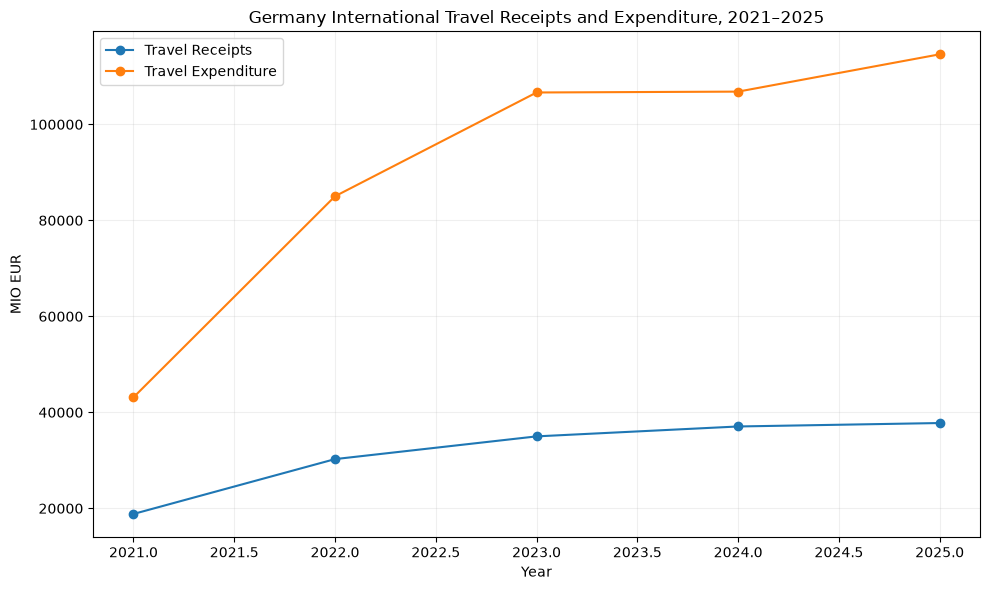

In [27]:
plt.figure(
    figsize=(10, 6)
)

plt.plot(
    germany_bop_annual[
        "year"
    ],
    germany_bop_annual[
        "travel_receipts_mio_eur"
    ],
    marker="o",
    label="Travel Receipts"
)

plt.plot(
    germany_bop_annual[
        "year"
    ],
    germany_bop_annual[
        "travel_expenditure_mio_eur"
    ],
    marker="o",
    label="Travel Expenditure"
)

plt.xlabel(
    "Year"
)

plt.ylabel(
    "MIO EUR"
)

plt.title(
    "Germany International Travel Receipts and Expenditure, 2021–2025"
)

plt.legend()

plt.grid(
    alpha=0.2
)

plt.tight_layout()

plt.savefig(
    figures_dir
    / "germany_travel_receipts_expenditure_2021_2025.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

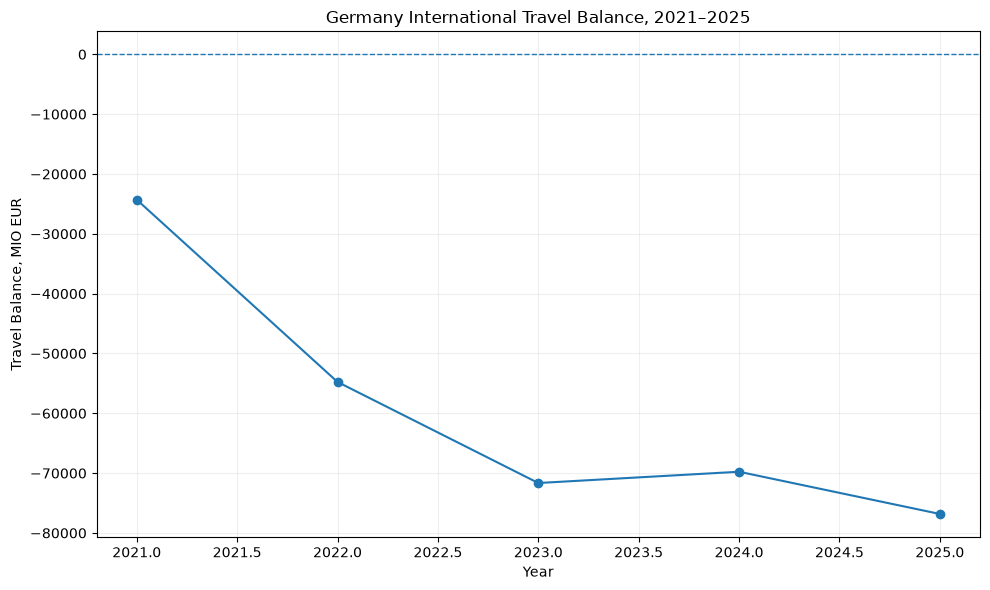

In [28]:
plt.figure(
    figsize=(10, 6)
)

plt.plot(
    germany_bop_annual[
        "year"
    ],
    germany_bop_annual[
        "travel_balance_mio_eur"
    ],
    marker="o"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel(
    "Year"
)

plt.ylabel(
    "Travel Balance, MIO EUR"
)

plt.title(
    "Germany International Travel Balance, 2021–2025"
)

plt.grid(
    alpha=0.2
)

plt.tight_layout()

plt.savefig(
    figures_dir
    / "germany_travel_balance_2021_2025.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [29]:
germany_bop_annual.to_csv(
    processed_dir
    / "germany_travel_bop_summary_2021_2025.csv",
    index=False
)

In [30]:
receipts_by_partner.to_csv(
    processed_dir
    / "germany_travel_receipts_by_partner_2021_2025.csv",
    index=False
)

In [31]:
partner_receipts_growth.to_csv(
    processed_dir
    / "germany_travel_receipts_partner_growth_2021_2025.csv",
    index=False
)

In [32]:
bop_identity.to_csv(
    processed_dir
    / "germany_travel_bop_identity_check.csv",
    index=False
)

In [33]:
economic_output_files = [
    "germany_travel_bop_summary_2021_2025.csv",
    "germany_travel_receipts_by_partner_2021_2025.csv",
    "germany_travel_receipts_partner_growth_2021_2025.csv",
    "germany_travel_bop_identity_check.csv"
]

for file_name in economic_output_files:
    file_path = (
        processed_dir
        / file_name
    )

    print(
        file_name,
        "->",
        file_path.exists()
    )

germany_travel_bop_summary_2021_2025.csv -> True
germany_travel_receipts_by_partner_2021_2025.csv -> True
germany_travel_receipts_partner_growth_2021_2025.csv -> True
germany_travel_bop_identity_check.csv -> True


In [34]:
for file_name in economic_output_files:
    check_df = pd.read_csv(
        processed_dir
        / file_name
    )

    print(
        file_name,
        check_df.shape
    )

germany_travel_bop_summary_2021_2025.csv (5, 12)
germany_travel_receipts_by_partner_2021_2025.csv (10, 12)
germany_travel_receipts_partner_growth_2021_2025.csv (10, 5)
germany_travel_bop_identity_check.csv (10, 8)


# Conclusion

Germany's international travel economy recovered strongly between 2021 and 2025, but inbound travel receipts did not keep pace with outbound travel expenditure.

Travel receipts increased by approximately 100.6% over the period, while travel expenditure increased by approximately 165.7%. As a result, Germany's negative travel balance widened substantially.

The deterioration was especially pronounced during 2022 and 2023. In 2024, the balance improved temporarily because receipts increased while expenditure remained almost unchanged. However, provisional 2025 data indicate a renewed widening of the deficit as expenditure growth again exceeded receipts growth.

The geographic structure of Germany's travel receipts remained relatively stable. EU27 partners consistently generated about two-thirds of receipts, while Extra-EU27 partners accounted for approximately one-third. Although Extra-EU27 receipts grew rapidly during the earlier recovery period, this momentum weakened by 2024 and turned slightly negative in provisional 2025.

These findings reinforce the broader competitiveness story developed in the project. Germany attracts substantial international tourism demand, but visitor scale alone does not fully determine economic performance. The combination of shorter stays, relatively modest inbound receipt growth, and substantially higher outbound travel expenditure contributes to a weaker external travel-economy position.

The negative travel balance should not be interpreted as a direct measure of tourism-sector profitability. Balance of Payments travel statistics reflect international travel credits and debits across the national economy and are broader in scope than the accommodation statistics used elsewhere in this project.

The 2025 results are provisional and should therefore be interpreted as the latest available indication rather than final annual values.